In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")
 
RESULTS_DIR = Path("../data/results")
csv_files = list(RESULTS_DIR.glob("routing_results_*.csv"))
print(f"Found {len(csv_files)} result files")

Found 4 result files


In [2]:
# Load all results
results_dfs = {}
for fp in csv_files:
    model_name = fp.stem.replace("routing_results_", "").replace("_", "/")
    df = pd.read_csv(fp)
    results_dfs[model_name] = df
    print(f"Loaded {model_name}: {len(df)} rows")

Loaded meta-llama/llama-3-8b-instruct: 100 rows
Loaded openai/gpt-4o-mini: 100 rows
Loaded anthropic/claude-sonnet-4.6: 100 rows
Loaded google/gemma-3-27b-it: 100 rows


In [3]:
# Router columns to evaluate
router_cols = [c for c in df.columns if c.endswith("_tool") and c not in ["ground_truth"]]
 
def compute_accuracy_table(df, routers):
    records = []
    for router in routers:
        acc = (df[router] == df["ground_truth"]).mean()
        records.append({"router": router, "overall_accuracy": acc})
        for tier in [1, 2, 3]:
            mask = df["ambiguity_tier"] == tier
            tier_acc = (df[mask][router] == df[mask]["ground_truth"]).mean()
            records.append({"router": f"{router}_tier_{tier}", "overall_accuracy": tier_acc})
    return pd.DataFrame(records)
 
# Example for first model
model_name = list(results_dfs.keys())[0]
df_model = results_dfs[model_name]
acc_df = compute_accuracy_table(df_model, router_cols)
print(acc_df)

                         router  overall_accuracy
0               rule_based_tool          0.360000
1        rule_based_tool_tier_1          0.700000
2        rule_based_tool_tier_2          0.133333
3        rule_based_tool_tier_3          0.133333
4             always_local_tool          0.520000
5      always_local_tool_tier_1          0.500000
6      always_local_tool_tier_2          0.633333
7      always_local_tool_tier_3          0.433333
8            zero_shot_llm_tool          0.740000
9     zero_shot_llm_tool_tier_1          0.950000
10    zero_shot_llm_tool_tier_2          0.600000
11    zero_shot_llm_tool_tier_3          0.600000
12            few_shot_llm_tool          0.770000
13     few_shot_llm_tool_tier_1          0.900000
14     few_shot_llm_tool_tier_2          0.733333
15     few_shot_llm_tool_tier_3          0.633333
16                 cot_llm_tool          0.750000
17          cot_llm_tool_tier_1          1.000000
18          cot_llm_tool_tier_2          0.600000


In [4]:
# Statistical Test 1: Chi-Square (Independence of Accuracy vs Ambiguity Tier)
# For each router, create contingency table: Correct/Incorrect × Tier 1/2/3
chi_results = {}
for router in router_cols:
    df_temp = df_model.copy()
    df_temp["is_correct"] = (df_temp[router] == df_temp["ground_truth"]).astype(int)
    # Contingency: tiers x correctness
    cont_table = pd.crosstab(df_temp["ambiguity_tier"], df_temp["is_correct"])
    if cont_table.shape == (3, 2):
        chi2, p, dof, expected = stats.chi2_contingency(cont_table)
        chi_results[router] = {"chi2": chi2, "p_value": p, "significant": p < 0.05}
 
chi_df = pd.DataFrame(chi_results).T
chi_df["interpretation"] = chi_df["p_value"].apply(lambda p: "Significant" if p < 0.05 else "Not Significant")
print("Chi-Square Test: Accuracy vs Ambiguity Tier")
print(chi_df)

Chi-Square Test: Accuracy vs Ambiguity Tier
                           chi2   p_value significant   interpretation
rule_based_tool       33.449074       0.0        True      Significant
always_local_tool      2.510684  0.284978       False  Not Significant
zero_shot_llm_tool    15.280665  0.000481        True      Significant
few_shot_llm_tool      7.208733  0.027205        True      Significant
cot_llm_tool          22.311111  0.000014        True      Significant
langgraph_agent_tool  20.007529  0.000045        True      Significant


In [5]:
# Statistical Test 2: One-Way ANOVA (Accuracy across ambiguity tiers)
anova_results = {}
for router in router_cols:
    tier_accuracies = []
    for tier in [1, 2, 3]:
        mask = df_model["ambiguity_tier"] == tier
        correctness = (df_model[mask][router] == df_model[mask]["ground_truth"]).astype(float).values
        tier_accuracies.append(correctness)
    f_stat, p_val = stats.f_oneway(*tier_accuracies)  # ✅ unpacked arrays of per-prompt correctness
    anova_results[router] = {"f_stat": f_stat, "p_value": p_val, "significant": p_val < 0.05}
 
anova_df = pd.DataFrame(anova_results).T
print("\nANOVA: Accuracy Variation Across Tiers")
print(anova_df)


ANOVA: Accuracy Variation Across Tiers
                         f_stat   p_value significant
rule_based_tool       24.376522       0.0        True
always_local_tool      1.249041   0.29135       False
zero_shot_llm_tool     8.747853  0.000321        True
few_shot_llm_tool       3.76785  0.026552        True
cot_llm_tool           13.92849  0.000005        True
langgraph_agent_tool  12.130706   0.00002        True


In [6]:
# Error Pattern Analysis
def analyze_errors(df, router):
    errors = df[df[router] != df["ground_truth"]]
    patterns = []
    for _, row in errors.iterrows():
        patterns.append({
            "query_id": row["query_id"],
            "ground_truth": row["ground_truth"],
            "predicted": row[router],
            "ambiguity_tier": row["ambiguity_tier"],
            "tags": row["prompt_tags"]
        })
    return pd.DataFrame(patterns)
 
print("Top Routing Errors (LangGraph Agent):")
errors_df = analyze_errors(df_model, "langgraph_agent_tool")
if not errors_df.empty:
    print(errors_df.head(10))
else:
    print("No errors found for this router.")

Top Routing Errors (LangGraph Agent):
   query_id ground_truth predicted  ambiguity_tier  \
0        12        local       web               2   
1        14        local       web               2   
2        16        local       web               2   
3        17        local       web               2   
4        18          web     local               2   
5        23        local       web               3   
6        26        local       web               3   
7        30        local       web               3   
8        61        local       web               2   
9        64        local       web               2   

                                                tags  
0  ['airbnb', 'risk_factors', '10K_section_or_web...  
1  ['amex', 'international', 'strategy', 'local_d...  
2  ['adobe', 'firefly', 'generative_AI', 'local_d...  
3  ['airbnb', 'KPIs', 'GBV', 'local_doc_or_web_su...  
4  ['amazon', 'shares_outstanding', 'current_web_...  
5  ['amazon', 'bare_query', 'growth',

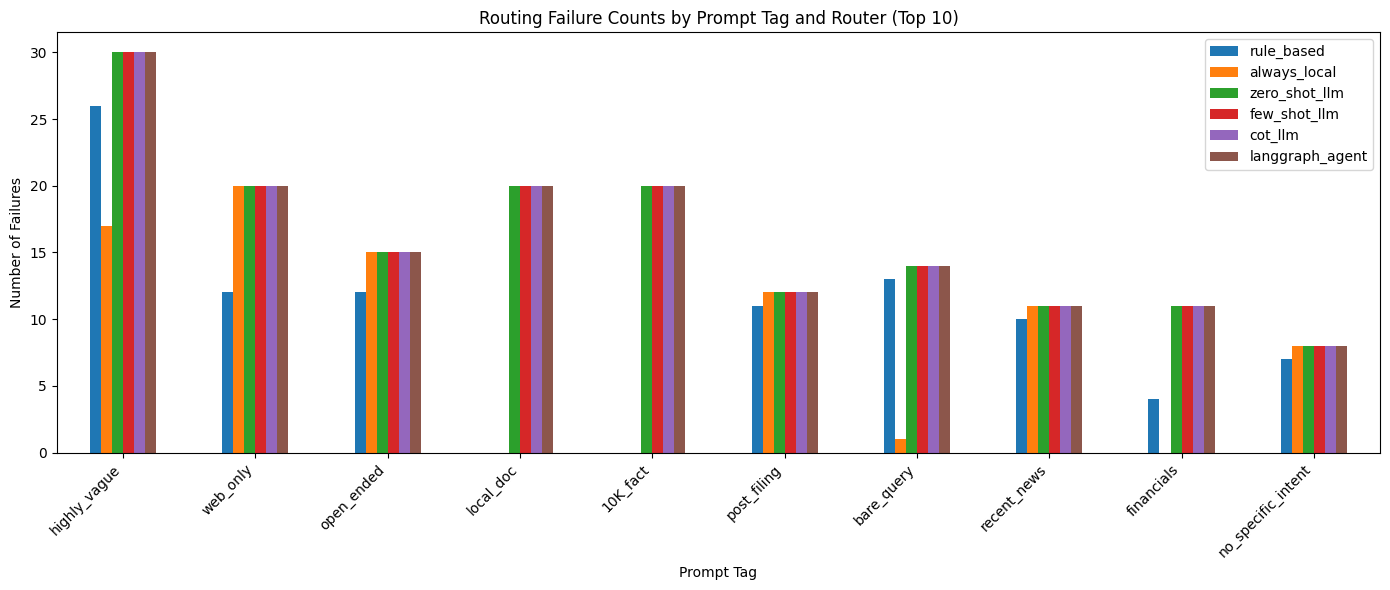

In [7]:
import matplotlib.pyplot as plt

failure_df = pd.read_csv("../data/results/failure_patterns.csv", index_col="prompt_tag")

# Sort by total failures across routers and keep the top 10 tags
top_failure_df = failure_df.assign(total_failures=failure_df.sum(axis=1)) \
    .sort_values("total_failures", ascending=False) \
    .drop(columns="total_failures") \
    .head(10)

# Plot failure counts per tag for each router
top_failure_df.plot(kind="bar", figsize=(14, 6))
plt.title("Routing Failure Counts by Prompt Tag and Router (Top 10)")
plt.xlabel("Prompt Tag")
plt.ylabel("Number of Failures")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/results/failure_patterns.png", dpi=150)
plt.show()